<a href="https://colab.research.google.com/github/minthukyaw488-commits/deeplearning/blob/master/DNABERT_AD_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 DNABERT for Alzheimer's Disease Classification

## Project Overview

This notebook applies **DNABERT** — a BERT model pre-trained on DNA sequences — to a multimodal neurogenomics dataset for **4-class disease stage classification**.

### Dataset Summary (N=734 subjects)
| File | Description | Shape |
|---|---|---|
| `X_SNP_1.npy` | SNP genotype data (0/1/2 dosage) | (734, 2098) |
| `X_GM.npy` | Gray matter MRI volumes (93 brain regions) | (734, 93) |
| `S_MMSE.npy` | MMSE cognitive score | (734,) |
| `C_age.npy` | Age | (734,) |
| `C_edu.npy` | Years of education | (734,) |
| `C_sex.npy` | Sex (M/F) | (734,) |
| `Y_dis.npy` | Disease label (one-hot, 4 classes) | (734, 4) |

### Disease Classes (likely)
- **Class 0**: CN — Cognitively Normal
- **Class 1**: sMCI — Stable Mild Cognitive Impairment
- **Class 2**: pMCI — Progressive MCI
- **Class 3**: AD — Alzheimer's Disease

### Approach
1. Convert SNP dosage → nucleotide pseudo-sequences → DNABERT embeddings
2. Process GM features independently
3. Fuse modalities and classify into 4 disease stages
4. Evaluate with accuracy, F1, AUC-ROC


## 1. Install Dependencies

In [1]:
!pip install transformers torch scikit-learn matplotlib seaborn umap-learn -q

## 2. Load Data

In [2]:
import numpy as np
import os

# ── Update this path if running on Colab ──
# Mount Google Drive if not already mounted
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/Bioinformatics'
# DATA_DIR = '.'  # Use this if files are in the same directory

# Verify the path and files existence before loading
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"DATA_DIR '{DATA_DIR}' does not exist. Please check the path or mount your Google Drive.")

age_info    = np.load(os.path.join(DATA_DIR, 'C_age.npy'))
edu_info    = np.load(os.path.join(DATA_DIR, 'C_edu.npy'))
gender_info = np.load(os.path.join(DATA_DIR, 'C_sex.npy'), allow_pickle=True)
cog_info    = np.load(os.path.join(DATA_DIR, 'S_MMSE.npy'))
mr_info     = np.load(os.path.join(DATA_DIR, 'X_GM.npy'))
gen_info    = np.load(os.path.join(DATA_DIR, 'X_SNP 1.npy'))
label_info  = np.load(os.path.join(DATA_DIR, 'Y_dis.npy'))

# Convert one-hot labels → integer class
y = np.argmax(label_info, axis=1)

CLASS_NAMES = ['CN', 'sMCI', 'pMCI', 'AD']

print(f'Subjects: {len(y)}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {(y == i).sum()} samples')
print(f'SNP features: {gen_info.shape[1]}')
print(f'GM regions:   {mr_info.shape[1]}')

Mounted at /content/drive
Subjects: 734
  CN: 211 samples
  sMCI: 194 samples
  pMCI: 156 samples
  AD: 173 samples
SNP features: 2098
GM regions:   93


## 3. Exploratory Data Analysis

/tmp/ipykernel_524/1224179676.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_class, labels=CLASS_NAMES, patch_artist=True,
/tmp/ipykernel_524/1224179676.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_edu, labels=CLASS_NAMES, patch_artist=True,


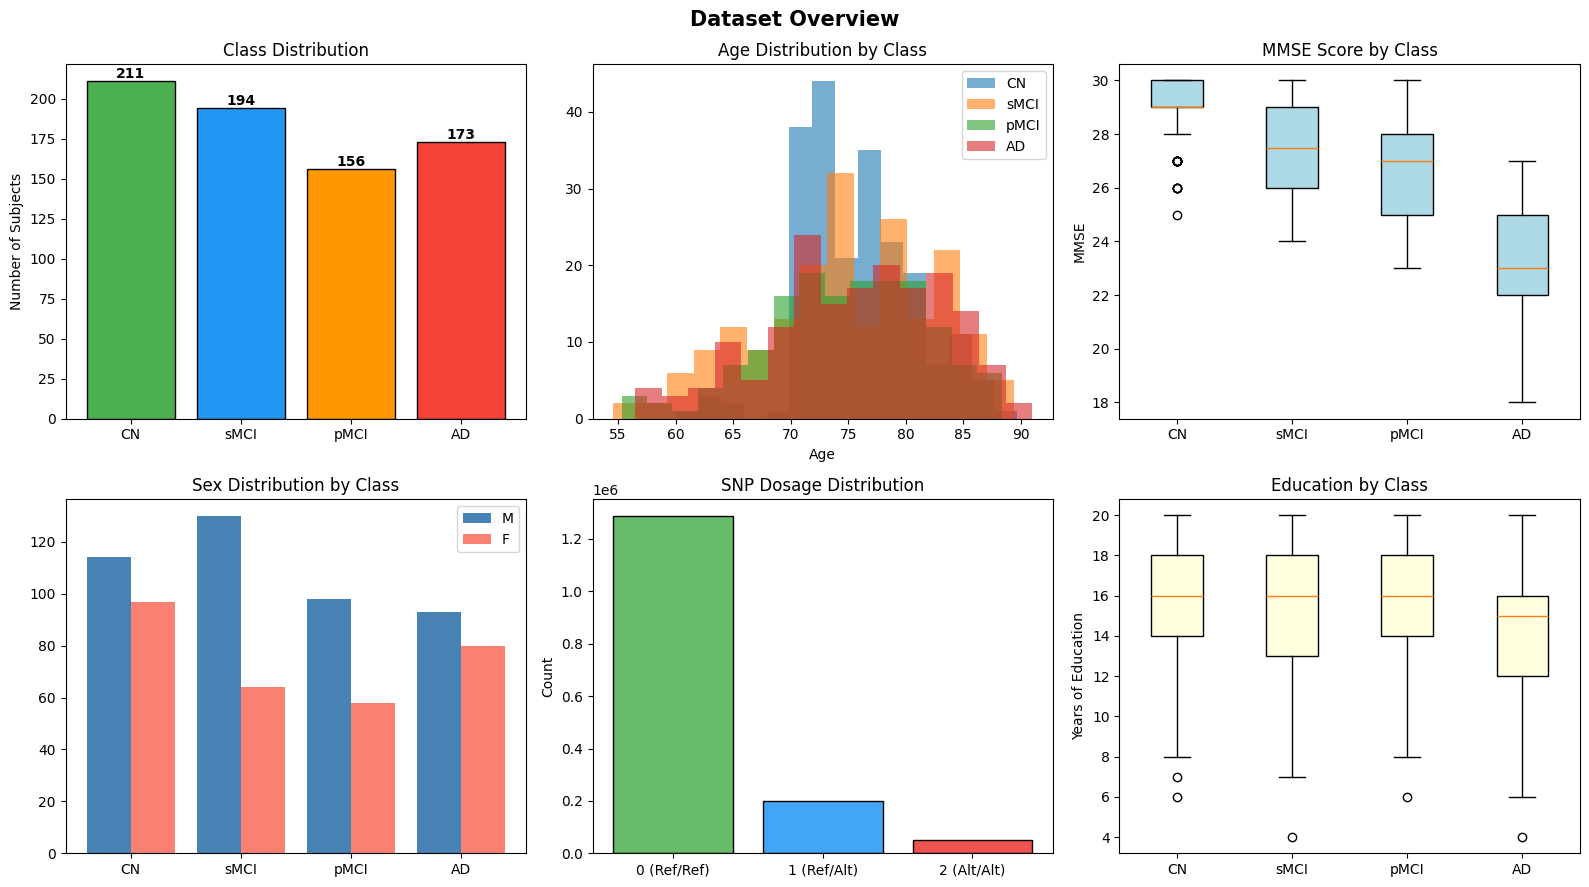

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dataset Overview', fontsize=15, fontweight='bold')

# Class distribution
ax = axes[0, 0]
counts = [(y == i).sum() for i in range(4)]
bars = ax.bar(CLASS_NAMES, counts, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'], edgecolor='black')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(c), ha='center', fontweight='bold')
ax.set_title('Class Distribution')
ax.set_ylabel('Number of Subjects')

# Age by class
ax = axes[0, 1]
for i, name in enumerate(CLASS_NAMES):
    ax.hist(age_info[y == i], bins=15, alpha=0.6, label=name)
ax.set_title('Age Distribution by Class')
ax.set_xlabel('Age')
ax.legend()

# MMSE by class
ax = axes[0, 2]
data_by_class = [cog_info[y == i] for i in range(4)]
ax.boxplot(data_by_class, labels=CLASS_NAMES, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('MMSE Score by Class')
ax.set_ylabel('MMSE')

# Sex distribution
ax = axes[1, 0]
for i, name in enumerate(CLASS_NAMES):
    mask = y == i
    m_count = (gender_info[mask] == 'M').sum()
    f_count = (gender_info[mask] == 'F').sum()
    ax.bar(i - 0.2, m_count, 0.4, label='M' if i == 0 else '', color='steelblue')
    ax.bar(i + 0.2, f_count, 0.4, label='F' if i == 0 else '', color='salmon')
ax.set_xticks(range(4))
ax.set_xticklabels(CLASS_NAMES)
ax.set_title('Sex Distribution by Class')
ax.legend()

# SNP dosage distribution
ax = axes[1, 1]
unique, counts_snp = np.unique(gen_info, return_counts=True)
ax.bar(['0 (Ref/Ref)', '1 (Ref/Alt)', '2 (Alt/Alt)'], counts_snp,
       color=['#66BB6A', '#42A5F5', '#EF5350'], edgecolor='black')
ax.set_title('SNP Dosage Distribution')
ax.set_ylabel('Count')

# Education by class
ax = axes[1, 2]
data_edu = [edu_info[y == i] for i in range(4)]
ax.boxplot(data_edu, labels=CLASS_NAMES, patch_artist=True,
           boxprops=dict(facecolor='lightyellow'))
ax.set_title('Education by Class')
ax.set_ylabel('Years of Education')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SNP → Nucleotide Sequence Conversion for DNABERT

DNABERT was pre-trained on nucleotide sequences (A, T, G, C). We encode each SNP dosage as a nucleotide pair:
- **0** (homozygous reference) → `AA`
- **1** (heterozygous) → `AC`  
- **2** (homozygous alternate) → `GG`

This produces a pseudo-DNA sequence of length **2098 × 2 = 4196 bp** per subject, which is then k-mer tokenized (k=6) for DNABERT input.

In [4]:
# SNP dosage → nucleotide encoding
SNP_TO_NUC = {0.0: 'AA', 1.0: 'AC', 2.0: 'GG'}

def snp_to_sequence(snp_row):
    """Convert a single subject's SNP dosage array to a nucleotide string."""
    return ''.join(SNP_TO_NUC[v] for v in snp_row)

def sequence_to_kmers(seq, k=6):
    """Convert a nucleotide sequence to space-separated k-mers (DNABERT format)."""
    return ' '.join([seq[i:i+k] for i in range(len(seq) - k + 1)])

# Test on one subject
sample_seq = snp_to_sequence(gen_info[0])
sample_kmers = sequence_to_kmers(sample_seq, k=6)

print(f'Sequence length: {len(sample_seq)} bp')
print(f'First 60 bases: {sample_seq[:60]}')
print(f'Number of 6-mers: {len(sample_kmers.split())}')
print(f'First 5 k-mers: {sample_kmers.split()[:5]}')

Sequence length: 4196 bp
First 60 bases: AAAAAAACAAAAAAAAACACAAAAAAAAACACACAAACACAAAAACAAAAACACACACAC
Number of 6-mers: 4191
First 5 k-mers: ['AAAAAA', 'AAAAAA', 'AAAAAC', 'AAAACA', 'AAACAA']


In [5]:
# Convert all subjects
print('Converting SNP data to nucleotide sequences...')
sequences = [snp_to_sequence(gen_info[i]) for i in range(len(gen_info))]
kmer_sequences = [sequence_to_kmers(seq, k=6) for seq in sequences]
print(f'Done. {len(kmer_sequences)} sequences ready for DNABERT.')

Converting SNP data to nucleotide sequences...
Done. 734 sequences ready for DNABERT.


## 5. Load DNABERT Tokenizer & Model

In [6]:
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# DNABERT-2 (recommended — no k-mer pre-tokenization needed)
# Uses BPE tokenization directly on nucleotide sequences
MODEL_NAME = 'zhihan1996/DNABERT-2-117M'

print(f'Loading tokenizer and model: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = model.to(device)
model.eval()
print('Model loaded.')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Using device: cuda
Loading tokenizer and model: zhihan1996/DNABERT-2-117M


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

configuration_bert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- configuration_bert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


flash_attn_triton.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- flash_attn_triton.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/zhihan1996/DNABERT-2-117M:
- bert_layers.py
- bert_padding.py
- flash_attn_triton.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/468M [00:00<?, ?B/s]

AttributeError: 'BertConfig' object has no attribute 'pad_token_id'

## 6. Extract DNABERT Embeddings

We use the **[CLS] token** output as a fixed-length embedding (768-dim) for each subject's SNP sequence.

In [ ]:
from torch.utils.data import DataLoader, Dataset

# DNABERT-2 max input length
MAX_LEN = 512
BATCH_SIZE = 8  # reduce if OOM

class SNPSequenceDataset(Dataset):
    def __init__(self, sequences, tokenizer, max_len):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        # Use raw nucleotide sequence (DNABERT-2 handles tokenization internally)
        seq = sequences[idx]  # raw sequence
        encoding = self.tokenizer(
            seq,
            return_tensors='pt',
            max_length=self.max_len,
            padding='max_length',
            truncation=True
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

dataset = SNPSequenceDataset(sequences, tokenizer, MAX_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

@torch.no_grad()
def extract_embeddings(model, loader, device):
    all_embeddings = []
    for batch_idx, batch in enumerate(loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        # CLS token embedding
        cls_embeddings = outputs[0][:, 0, :]  # (batch, hidden_dim)
        all_embeddings.append(cls_embeddings.cpu().numpy())
        if (batch_idx + 1) % 10 == 0:
            print(f'  Processed {(batch_idx+1)*BATCH_SIZE}/{len(dataset)} subjects')
    return np.vstack(all_embeddings)

print('Extracting DNABERT embeddings...')
snp_embeddings = extract_embeddings(model, loader, device)
print(f'Done! SNP embeddings shape: {snp_embeddings.shape}')

# Save for reuse
np.save('snp_dnabert_embeddings.npy', snp_embeddings)

## 7. Prepare Features for Classification

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit

# Encode sex: M=1, F=0
le = LabelEncoder()
sex_encoded = le.fit_transform(gender_info).reshape(-1, 1)

# Normalize continuous features
scaler_cov = StandardScaler()
covariates = scaler_cov.fit_transform(
    np.column_stack([age_info, edu_info, cog_info, sex_encoded])
)  # shape: (734, 4)

scaler_gm = StandardScaler()
gm_features = scaler_gm.fit_transform(mr_info)  # shape: (734, 93)

scaler_emb = StandardScaler()
snp_emb = scaler_emb.fit_transform(snp_embeddings)  # shape: (734, 768)

# Fuse all modalities
X_all = np.concatenate([snp_emb, gm_features, covariates], axis=1)
y_labels = np.argmax(label_info, axis=1)

print('Feature dimensions:')
print(f'  DNABERT SNP embeddings : {snp_emb.shape[1]}')
print(f'  GM MRI features        : {gm_features.shape[1]}')
print(f'  Covariates             : {covariates.shape[1]}')
print(f'  Total (fused)          : {X_all.shape[1]}')

# Stratified 80/10/10 split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(sss.split(X_all, y_labels))
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(sss2.split(X_all[temp_idx], y_labels[temp_idx]))
val_idx  = temp_idx[val_idx]
test_idx = temp_idx[test_idx]

X_train, y_train = X_all[train_idx], y_labels[train_idx]
X_val,   y_val   = X_all[val_idx],   y_labels[val_idx]
X_test,  y_test  = X_all[test_idx],  y_labels[test_idx]

print(f'\nSplit → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

## 8. Train Classifier — MLP (PyTorch)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class MultimodalMLP(nn.Module):
    def __init__(self, input_dim, num_classes=4, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def make_loader(X, y, batch_size=32, shuffle=True):
    X_t = torch.FloatTensor(X)
    y_t = torch.LongTensor(y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   shuffle=False)
test_loader  = make_loader(X_test,  y_test,  shuffle=False)

clf = MultimodalMLP(X_all.shape[1], num_classes=4).to(device)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None, train=True):
    model.train(train)
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss = criterion(logits, y_b)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_b)
            correct += (logits.argmax(1) == y_b).sum().item()
            total += len(y_b)
    return total_loss / total, correct / total

EPOCHS = 100
best_val_acc = 0
train_losses, val_losses, train_accs, val_accs = [], [], [], []

print(f'Training for {EPOCHS} epochs...')
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(clf, train_loader, optimizer, train=True)
    vl_loss, vl_acc = run_epoch(clf, val_loader, train=False)
    scheduler.step()
    train_losses.append(tr_loss); val_losses.append(vl_loss)
    train_accs.append(tr_acc);    val_accs.append(vl_acc)
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(clf.state_dict(), 'best_model.pt')
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}')

print(f'\nBest Validation Accuracy: {best_val_acc:.4f}')

## 9. Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train')
ax1.plot(val_losses, label='Val')
ax1.set_title('Cross-Entropy Loss')
ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(train_accs, label='Train')
ax2.plot(val_accs, label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 10. Evaluation on Test Set

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

# Load best model
clf.load_state_dict(torch.load('best_model.pt'))
clf.eval()

all_preds, all_probs, all_true = [], [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = clf(X_b.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(y_b.numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_true  = np.array(all_true)

print('=== Classification Report ===')
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

y_bin = label_binarize(all_true, classes=[0,1,2,3])
auc = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')
print(f'Macro AUC-ROC: {auc:.4f}')

## 11. Confusion Matrix

In [ ]:
cm = confusion_matrix(all_true, all_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_pct],
    ['d', '.1f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (%)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 12. Embedding Visualization (UMAP)

Visualize the DNABERT SNP embeddings in 2D to see how well the disease classes separate in genetic space.

In [ ]:
import umap

print('Running UMAP on DNABERT SNP embeddings...')
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
emb_2d = reducer.fit_transform(snp_embeddings)

colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
fig, ax = plt.subplots(figsize=(9, 7))
for i, name in enumerate(CLASS_NAMES):
    mask = y_labels == i
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=colors[i], label=name, alpha=0.7, s=20, edgecolors='none')
ax.set_title('UMAP of DNABERT SNP Embeddings', fontsize=13)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(title='Disease Stage', markerscale=2)
plt.tight_layout()
plt.savefig('umap_snp_embeddings.png', dpi=150)
plt.show()

## 13. Ablation Study — Contribution of Each Modality

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

modalities = {
    'SNP (DNABERT)': snp_emb,
    'GM MRI': gm_features,
    'Covariates': covariates,
    'SNP + GM': np.concatenate([snp_emb, gm_features], axis=1),
    'All (Fused)': X_all,
}

results = []
for name, X_mod in modalities.items():
    X_tr = X_mod[train_idx]
    X_te = X_mod[test_idx]
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_train)
    preds = rf.predict(X_te)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    results.append({'Modality': name, 'Accuracy': acc, 'F1 (macro)': f1})
    print(f'{name:25s} | Acc: {acc:.3f} | F1: {f1:.3f}')

# Plot
import pandas as pd
df_res = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_res))
ax.bar(x - 0.2, df_res['Accuracy'], 0.4, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, df_res['F1 (macro)'], 0.4, label='F1 (macro)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(df_res['Modality'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Ablation: Contribution of Each Modality (Random Forest)')
ax.legend()
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150)
plt.show()

## 14. Summary

| Component | Detail |
|---|---|
| **Model** | DNABERT-2 (117M params, BPE tokenization) |
| **SNP encoding** | Dosage 0/1/2 → nucleotide pairs AA/AC/GG |
| **Embedding** | CLS token, 768-dim |
| **Classifier** | 3-layer MLP with BatchNorm + Dropout |
| **Modalities** | DNABERT SNP + Gray Matter MRI + Covariates |
| **Task** | 4-class: CN / sMCI / pMCI / AD |

### Next Steps
- Fine-tune DNABERT end-to-end instead of just embedding extraction
- Try cross-attention fusion between SNP and GM modalities
- Add SHAP analysis to identify which SNPs drive predictions
- Experiment with different k values in k-mer tokenization